In [11]:
from frb.surveys import survey_utils as su
from frb.surveys import catalog_utils as cu

from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord
from astropy import units as u

import numpy as np
import matplotlib.pyplot as plt

# Finding GOTOQ candidates in DESI

## Get UV-bright QSOs first

In [109]:
# Write a custom query to get all QSOs in DESI

query_str ="""
            SELECT
                targetid, mean_fiber_ra AS ra, mean_fiber_dec AS dec, z, zerr, survey, zcat_primary as DESI_zcat_primary, zwarn
            FROM
                desi_dr1.zpix
            WHERE
                spectype = 'QSO'
            """

coord = SkyCoord(ra=0*u.degree, dec=0*u.degree, frame='icrs')
survey = su.load_survey_by_name("DESI", coord, radius=180*u.degree) # The coord and radius are not important here since we are doing a custom query
desi_qsos = survey.get_catalog(query = query_str, zcat_primary_only=False)

In [110]:
desi_qsos['DESI_z'][desi_qsos['DESI_ID'] == 39628066271533460]

0.09663994610737323


In [111]:
desi_qsos = desi_qsos[desi_qsos['DESI_z_warn'] == 0] # Keep only objects with good redshifts (zwarn = 0)
desi_qsos

DESI_ID,ra,dec,DESI_z,DESI_z_err,DESI_survey,desi_zcat_primary,DESI_z_warn
int64,float64,float64,float64,float64,str7,str1,int64
39633272153575475,282.6820727641004,51.54272840884439,1.5894929001188,0.00156040342756772,main,t,0
39633260719903708,279.2159301122258,50.71978084338487,1.65862810720412,0.0007186566126100288,main,t,0
39633196777735931,270.3075888881637,46.86067398390855,1.203424147428416,0.0003773044318294931,main,t,0
39633249042958318,270.3644464046807,49.8844989503573,3.456981801356528,0.0005042462732529919,main,t,0
39633279531356196,271.7008468188831,51.91693567429949,2.211767772416707,0.0007308342855100358,main,t,0
39633336569695942,280.9926199776978,56.00824593329872,1.358799302749667,0.001261604932009873,main,t,0
39633359650947919,271.0060292856074,57.87430765003908,1.871450675145537,0.0005594531682136996,main,t,0
39633387866032890,274.7623169400877,59.98473175736429,2.808010433869499,0.000848435156106506,main,t,0
39633372393246913,270.6988216365964,58.79011748171182,1.007275205468272,0.0001728777883572823,main,t,0


In [112]:
desi_qsos.write("desi_qsos.csv", format="csv", overwrite=True)

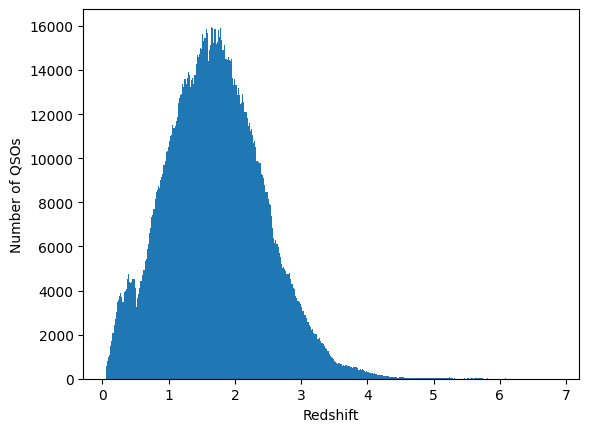

In [113]:
desi_qsos = Table.read("desi_qsos.csv", format="csv")
plt.hist(desi_qsos['DESI_z'], bins='auto')
plt.xlabel("Redshift")
plt.ylabel("Number of QSOs")
plt.show()

In [114]:
# Similar search but I ran the query on CASJobs for a faster reponse
# import mastcasjobs as mcj
# import os

# Query
query_str = """
                SELECT 
                    p.objid, p.ra, p.dec, p.nuv_mag, p.nuv_magerr, p.fuv_mag, p.fuv_magerr, pe.mpstype AS survey
                FROM
                    photoobjall AS p, photoextract AS pe
                INTO
                    mydb.galex_fuv_bright_sources
                WHERE
                    p.photoextractid=pe.photoextractid AND p.fuv_mag<18.5
            """
# # Execute
# user = os.getenv('MAST_CASJOBS_USER')
# pwd = os.getenv('MAST_CASJOBS_PWD')

# job = mcj.MastCasJobs(context="GALEX_GR6Plus7", username=user, password=pwd)
# galex_tab = job.submit(query_str, task_name="Galex FUV bright sources")
# galex_tab

galex_tab = Table.read("galex_bright.csv", format="csv")

In [115]:
# Cross match
matched_qso, matched_galex = cu.xmatch_catalogs(desi_qsos, galex_tab, dist=2*u.arcsec)

idx, d2d, _= cu.xmatch_catalogs(desi_qsos, galex_tab,
                              dist=2*u.arcsec, return_match_idx=True)

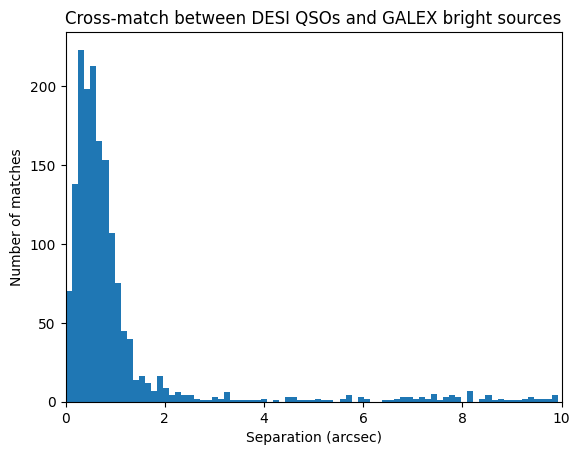

In [116]:
limit = 10*u.arcsec
plt.hist(d2d.arcsec[d2d<limit], bins='auto')
plt.xlabel("Separation (arcsec)")
plt.ylabel("Number of matches")
plt.title("Cross-match between DESI QSOs and GALEX bright sources")
plt.xlim(0, 10)
plt.show()

In [117]:
matched_qso['GALEX_FUV_MAG'] = matched_galex['fuv_mag']
matched_qso.sort(['DESI_z','ra', 'dec'])
matched_qso

DESI_ID,ra,dec,DESI_z,DESI_z_err,DESI_survey,desi_zcat_primary,DESI_z_warn,GALEX_FUV_MAG
int64,float64,float64,float64,float64,str7,str1,int64,float64
2305843021695943910,195.0832434173324,61.65503651806954,0.05222483039988823,4.65412308321073e-06,main,t,0,17.9436645507813
2305843018785096852,215.5841609635079,29.71528178124287,0.05292468469785445,4.831989425569241e-06,main,t,0,17.2959899902344
39628475996311491,215.5841686862564,29.71527221044749,0.05294380517822361,5.133627535689339e-06,main,t,0,17.2959899902344
39632985812635075,181.4577967237062,35.17944933617638,0.05377199939710087,2.640120139863352e-06,main,t,0,17.4759922027588
2305843039236528742,181.4577658596346,35.17940421767707,0.05378324654978045,2.810581107846241e-06,main,t,0,17.4759922027588
2305843036527004194,214.1284010004999,1.618935536294424,0.05419148179005401,5.844902670447806e-06,main,t,0,17.8516368865967
39627824557984211,214.1283944026409,1.618923761297891,0.05422736428114017,6.700759245033133e-06,main,t,0,17.8516368865967
2305843020412486280,206.1100827938952,44.27222139073776,0.0549346510470639,4.122752226436085e-06,main,t,0,17.4355182647705
39633259839097338,196.4458800977272,50.67614746766068,0.05537880126489214,3.082500251422336e-06,main,t,0,17.9577655792236


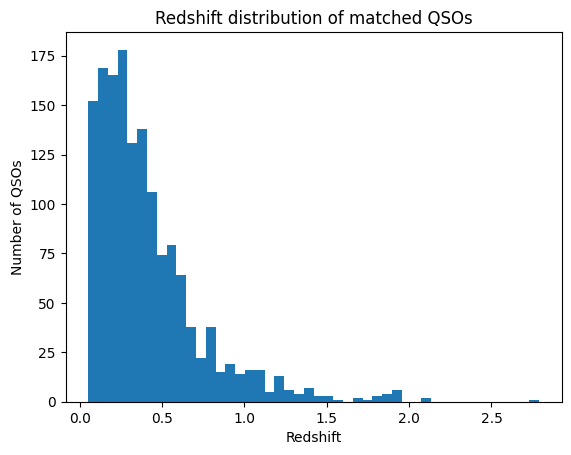

In [118]:
plt.hist(matched_qso['DESI_z'], bins='auto')
plt.xlabel("Redshift")
plt.ylabel("Number of QSOs")
plt.title("Redshift distribution of matched QSOs")
plt.show()


## Search for extended sources in the Legacy Survey near the UV bright quasars

In [119]:
import tqdm

# TODO: This can be sped up in a variety of ways, e.g. by doing bulk queries to the survey instead of one query per source, or by parallelizing the queries. But for now this is good enough. Takes about 10 min for the 1500 sources in the matched_qso table.

master_tab = []
for entry in tqdm.tqdm(matched_qso):
    qso_coord = SkyCoord(ra=entry['ra']*u.degree, dec=entry['dec']*u.degree)
    survey = su.load_survey_by_name('DECaL', coord = qso_coord,
                                    radius=1*u.arcsec)
    cat = survey.get_catalog()
    if cat != None and len(cat)>0:
        cat['survey'] = cat['survey'].astype(str) # Convert from int to string
        cat['ang_dist_arcsec'] = qso_coord.separation(SkyCoord(ra=cat['ra']*u.degree, dec=cat['dec']*u.degree)).arcsec
        cat['DESI_QSO_ID'] = entry['DESI_ID']
        cat['QSO_z'] = entry['DESI_z']
        cat['QSO_ra'] = entry['ra']
        cat['QSO_dec'] = entry['dec']
        cat['QSO_zcat_primary'] = entry['desi_zcat_primary']
        master_tab.append(cat)
master_tab = vstack(master_tab)
master_tab

100%|██████████| 1495/1495 [08:45<00:00,  2.84it/s]


z_phot_median,z_spec,survey,z_phot_l68,z_phot_u68,z_phot_l95,z_phot_u95,DECaL_g,DECaL_g_err,DECaL_r,DECaL_r_err,DECaL_z,DECaL_z_err,DECaL_ID,ra,dec,DECaL_brick,DECaL_type,ang_dist_arcsec,DESI_QSO_ID,QSO_z,QSO_ra,QSO_dec,QSO_zcat_primary
float64,float64,str21,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,str3,float64,int64,float64,float64,float64,str1
0.0,0.0,0,0.0,0.0,0.0,0.0,inf,-99.0,inf,-99.0,inf,-99.0,9907740070972578,195.08322939139683,61.65504222155494,622453,DUP,0.03156420982306679,2305843021695943910,0.05222483039988823,195.0832434173324,61.65503651806954,t
0.0,0.0,0,0.0,0.0,0.0,0.0,15.353884,0.0008611991626752801,14.566691,0.0007339072174724459,14.078948,0.0005243621913820758,9907740070971629,195.0832067520055,61.655038554407945,622453,SER,0.0630958536478331,2305843021695943910,0.05222483039988823,195.0832434173324,61.65503651806954,t
0.038120575,-99.0,0,0.032294944,0.052060407,0.02832202,0.06730145,15.402603,0.00040835127703075537,14.870779,0.000490202694874227,14.378546,0.00041693871286043734,10995635510579136,215.5841457419769,29.71527975737906,495179,SER,0.04814608139624597,2305843018785096852,0.05292468469785445,215.5841609635079,29.71528178124287,t
-99.0,-99.0,0,-99.0,-99.0,-99.0,-99.0,inf,-99.0,inf,-99.0,inf,-99.0,10995635510580416,215.5841450099247,29.71529233277274,495179,DUP,0.06269733910442918,2305843018785096852,0.05292468469785445,215.5841609635079,29.71528178124287,t
0.038120575,-99.0,0,0.032294944,0.052060407,0.02832202,0.06730145,15.402603,0.00040835127703075537,14.870779,0.000490202694874227,14.378546,0.00041693871286043734,10995635510579136,215.5841457419769,29.71527975737906,495179,SER,0.07671001084840705,39628475996311491,0.05294380517822361,215.5841686862564,29.71527221044749,t
-99.0,-99.0,0,-99.0,-99.0,-99.0,-99.0,inf,-99.0,inf,-99.0,inf,-99.0,10995635510580416,215.5841450099247,29.71529233277274,495179,DUP,0.10357369147308129,39628475996311491,0.05294380517822361,215.5841686862564,29.71527221044749,t
0.0,0.0,0,0.0,0.0,0.0,0.0,inf,-99.0,inf,-99.0,inf,-99.0,9907733476348341,181.4577743610095,35.179417142909216,521827,DUP,0.13327288796230025,39632985812635075,0.05377199939710087,181.4577967237062,35.17944933617638,t
0.0,0.0,0,0.0,0.0,0.0,0.0,15.32561,0.0005405882367643731,14.753216,0.000633834676069939,14.438549,0.00042302608768404694,9907733476347331,181.4577917025673,35.179433298900584,521827,SER,0.05959466236249026,39632985812635075,0.05377199939710087,181.4577967237062,35.17944933617638,t
0.0,0.0,0,0.0,0.0,0.0,0.0,inf,-99.0,inf,-99.0,inf,-99.0,9907733476348341,181.4577743610095,35.179417142909216,521827,DUP,0.05282868272458384,2305843039236528742,0.05378324654978045,181.4577658596346,35.17940421767707,t


In [120]:
master_tab.write("desi_fuv_bright_qsosxdecals.csv",
                 format="csv", overwrite=True)

In [121]:
master_tab = Table.read("desi_fuv_bright_qsosxdecals.csv")
master_tab

z_phot_median,z_spec,survey,z_phot_l68,z_phot_u68,z_phot_l95,z_phot_u95,DECaL_g,DECaL_g_err,DECaL_r,DECaL_r_err,DECaL_z,DECaL_z_err,DECaL_ID,ra,dec,DECaL_brick,DECaL_type,ang_dist_arcsec,DESI_QSO_ID,QSO_z,QSO_ra,QSO_dec,QSO_zcat_primary
float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,str3,float64,int64,float64,float64,float64,str1
0.0,0.0,0,0.0,0.0,0.0,0.0,inf,-99.0,inf,-99.0,inf,-99.0,9907740070972578,195.08322939139683,61.65504222155494,622453,DUP,0.03156420982306679,2305843021695943910,0.05222483039988823,195.0832434173324,61.65503651806954,t
0.0,0.0,0,0.0,0.0,0.0,0.0,15.353884,0.0008611991626752801,14.566691,0.0007339072174724459,14.078948,0.0005243621913820758,9907740070971629,195.0832067520055,61.655038554407945,622453,SER,0.0630958536478331,2305843021695943910,0.05222483039988823,195.0832434173324,61.65503651806954,t
0.038120575,-99.0,0,0.032294944,0.052060407,0.02832202,0.06730145,15.402603,0.00040835127703075537,14.870779,0.000490202694874227,14.378546,0.00041693871286043734,10995635510579136,215.5841457419769,29.71527975737906,495179,SER,0.04814608139624597,2305843018785096852,0.05292468469785445,215.5841609635079,29.71528178124287,t
-99.0,-99.0,0,-99.0,-99.0,-99.0,-99.0,inf,-99.0,inf,-99.0,inf,-99.0,10995635510580416,215.5841450099247,29.71529233277274,495179,DUP,0.06269733910442918,2305843018785096852,0.05292468469785445,215.5841609635079,29.71528178124287,t
0.038120575,-99.0,0,0.032294944,0.052060407,0.02832202,0.06730145,15.402603,0.00040835127703075537,14.870779,0.000490202694874227,14.378546,0.00041693871286043734,10995635510579136,215.5841457419769,29.71527975737906,495179,SER,0.07671001084840705,39628475996311491,0.05294380517822361,215.5841686862564,29.71527221044749,t
-99.0,-99.0,0,-99.0,-99.0,-99.0,-99.0,inf,-99.0,inf,-99.0,inf,-99.0,10995635510580416,215.5841450099247,29.71529233277274,495179,DUP,0.10357369147308129,39628475996311491,0.05294380517822361,215.5841686862564,29.71527221044749,t
0.0,0.0,0,0.0,0.0,0.0,0.0,inf,-99.0,inf,-99.0,inf,-99.0,9907733476348341,181.4577743610095,35.179417142909216,521827,DUP,0.13327288796230025,39632985812635075,0.05377199939710087,181.4577967237062,35.17944933617638,t
0.0,0.0,0,0.0,0.0,0.0,0.0,15.32561,0.0005405882367643731,14.753216,0.000633834676069939,14.438549,0.00042302608768404694,9907733476347331,181.4577917025673,35.179433298900584,521827,SER,0.05959466236249026,39632985812635075,0.05377199939710087,181.4577967237062,35.17944933617638,t
0.0,0.0,0,0.0,0.0,0.0,0.0,inf,-99.0,inf,-99.0,inf,-99.0,9907733476348341,181.4577743610095,35.179417142909216,521827,DUP,0.05282868272458384,2305843039236528742,0.05378324654978045,181.4577658596346,35.17940421767707,t


In [122]:
# Sources whose type is not PSF
extended_sources = master_tab[master_tab['DECaL_type'] != 'PSF']
extended_sources

z_phot_median,z_spec,survey,z_phot_l68,z_phot_u68,z_phot_l95,z_phot_u95,DECaL_g,DECaL_g_err,DECaL_r,DECaL_r_err,DECaL_z,DECaL_z_err,DECaL_ID,ra,dec,DECaL_brick,DECaL_type,ang_dist_arcsec,DESI_QSO_ID,QSO_z,QSO_ra,QSO_dec,QSO_zcat_primary
float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,str3,float64,int64,float64,float64,float64,str1
0.0,0.0,0,0.0,0.0,0.0,0.0,inf,-99.0,inf,-99.0,inf,-99.0,9907740070972578,195.08322939139683,61.65504222155494,622453,DUP,0.03156420982306679,2305843021695943910,0.05222483039988823,195.0832434173324,61.65503651806954,t
0.0,0.0,0,0.0,0.0,0.0,0.0,15.353884,0.0008611991626752801,14.566691,0.0007339072174724459,14.078948,0.0005243621913820758,9907740070971629,195.0832067520055,61.655038554407945,622453,SER,0.0630958536478331,2305843021695943910,0.05222483039988823,195.0832434173324,61.65503651806954,t
0.038120575,-99.0,0,0.032294944,0.052060407,0.02832202,0.06730145,15.402603,0.00040835127703075537,14.870779,0.000490202694874227,14.378546,0.00041693871286043734,10995635510579136,215.5841457419769,29.71527975737906,495179,SER,0.04814608139624597,2305843018785096852,0.05292468469785445,215.5841609635079,29.71528178124287,t
-99.0,-99.0,0,-99.0,-99.0,-99.0,-99.0,inf,-99.0,inf,-99.0,inf,-99.0,10995635510580416,215.5841450099247,29.71529233277274,495179,DUP,0.06269733910442918,2305843018785096852,0.05292468469785445,215.5841609635079,29.71528178124287,t
0.038120575,-99.0,0,0.032294944,0.052060407,0.02832202,0.06730145,15.402603,0.00040835127703075537,14.870779,0.000490202694874227,14.378546,0.00041693871286043734,10995635510579136,215.5841457419769,29.71527975737906,495179,SER,0.07671001084840705,39628475996311491,0.05294380517822361,215.5841686862564,29.71527221044749,t
-99.0,-99.0,0,-99.0,-99.0,-99.0,-99.0,inf,-99.0,inf,-99.0,inf,-99.0,10995635510580416,215.5841450099247,29.71529233277274,495179,DUP,0.10357369147308129,39628475996311491,0.05294380517822361,215.5841686862564,29.71527221044749,t
0.0,0.0,0,0.0,0.0,0.0,0.0,inf,-99.0,inf,-99.0,inf,-99.0,9907733476348341,181.4577743610095,35.179417142909216,521827,DUP,0.13327288796230025,39632985812635075,0.05377199939710087,181.4577967237062,35.17944933617638,t
0.0,0.0,0,0.0,0.0,0.0,0.0,15.32561,0.0005405882367643731,14.753216,0.000633834676069939,14.438549,0.00042302608768404694,9907733476347331,181.4577917025673,35.179433298900584,521827,SER,0.05959466236249026,39632985812635075,0.05377199939710087,181.4577967237062,35.17944933617638,t
0.0,0.0,0,0.0,0.0,0.0,0.0,inf,-99.0,inf,-99.0,inf,-99.0,9907733476348341,181.4577743610095,35.179417142909216,521827,DUP,0.05282868272458384,2305843039236528742,0.05378324654978045,181.4577658596346,35.17940421767707,t


In [128]:
# Foreground according to DECaL photo-z?
# Not to be trusted but worth looking into
photoz_foreground = extended_sources[(extended_sources['z_phot_median'] < extended_sources['QSO_z']) & (extended_sources['z_phot_median'] > 0)]
photoz_foreground = photoz_foreground[photoz_foreground['QSO_z'] > 0.1] # Keep only extended sources
photoz_foreground

z_phot_median,z_spec,survey,z_phot_l68,z_phot_u68,z_phot_l95,z_phot_u95,DECaL_g,DECaL_g_err,DECaL_r,DECaL_r_err,DECaL_z,DECaL_z_err,DECaL_ID,ra,dec,DECaL_brick,DECaL_type,ang_dist_arcsec,DESI_QSO_ID,QSO_z,QSO_ra,QSO_dec,QSO_zcat_primary
float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,str3,float64,int64,float64,float64,float64,str1
0.05797007,0.103,GAMA,0.041993275,0.24700643,0.02681723,0.42584962,16.39222,0.0008604194982123723,15.938227,0.0006823004468136777,15.476174,0.000931517095567564,10995452898968696,184.7863964116684,-1.808079246913791,321027,SER,0.041874926407562775,39627745549878036,0.1031714254290561,184.7863941742122,-1.808090661835147,t
0.05797007,0.103,GAMA,0.041993275,0.24700643,0.02681723,0.42584962,16.39222,0.0008604194982123723,15.938227,0.0006823004468136777,15.476174,0.000931517095567564,10995452898968696,184.7863964116684,-1.808079246913791,321027,SER,0.045662817695397026,2305843036736719944,0.1032182988736462,184.7864071956531,-1.808072560491382,t
0.07981789,-99.0,0,0.052512355,0.10177873,0.032839023,0.14246833,16.289427,0.000740933605839936,15.976455,0.0007259419296642197,15.47204,0.0008492639724296065,10995636955512940,252.0033626133929,29.94929956495416,496557,SER,0.03379481060786387,39628481776058477,0.1061598129838243,252.0033730204221,29.94930217484338,t
0.09156232,-99.0,0,0.0632919,0.11655562,0.04878273,0.16471113,17.00249,0.0007783454501480147,16.389559,0.00046520908360558866,15.781343,0.0005781885247157136,10995377545157341,21.27248211010181,-14.3555518097127,249164,SER,0.16306563870909002,39627444134615157,0.1229245498634021,21.27250269475519,-14.35551113971656,t
0.08038981,0.12855373,SDSS-QSO,0.046869565,0.1050231,0.028832635,0.12211913,16.450464,0.0006867771573027317,15.875535,0.0005077445527989178,15.318666,0.0005880064928739208,10995485416363385,18.67487273800947,3.821059344924703,352038,SER,0.06355916315455992,39627875619443626,0.1289698353245917,18.67487500203333,3.821041834716447,t
0.08038981,0.12855373,SDSS-QSO,0.046869565,0.1050231,0.028832635,0.12211913,16.450464,0.0006867771573027317,15.875535,0.0005077445527989178,15.318666,0.0005880064928739208,10995485416363385,18.67487273800947,3.821059344924703,352038,SER,0.09281804847832271,2851410693586944,0.1289711371134606,18.67488499424326,3.821036646815621,t
0.078177854,-99.0,0,0.050523754,0.10008162,0.035345923,0.11911295,16.600077,0.0008966873200996432,16.091612,0.0008756650853105224,15.556273,0.0008993094978577403,10995512922607147,127.3774450072406,8.210558832630218,378270,SER,0.04096973864845665,39627985644424343,0.1296000574239224,127.3774478799359,8.21056985221833,t
0.09458972,-99.0,0,0.0721211,0.12333117,0.044280797,0.1467256,16.86468,0.0009462765852919991,16.35477,0.0007809264465973301,15.789209,0.0006608686241528388,10995572131500585,231.4938755797482,18.23779594507172,434736,SER,0.029746286754503373,39628222479995428,0.1300427908239526,231.4938669096912,18.23779526138147,t
0.12336197,-99.0,0,0.10216852,0.15424559,0.08311533,0.20603134,17.311129,0.0008151308946408958,16.906796,0.0002806838195646702,16.48103,0.000904969059890717,10995484639368479,193.113859556064,3.398221912036491,351297,SER,0.0229818960409431,39627872511462000,0.1332539674027112,193.1138652745863,3.398224769845207,t


Number of unique QSOs with foreground according to DECaL photo-z: 81


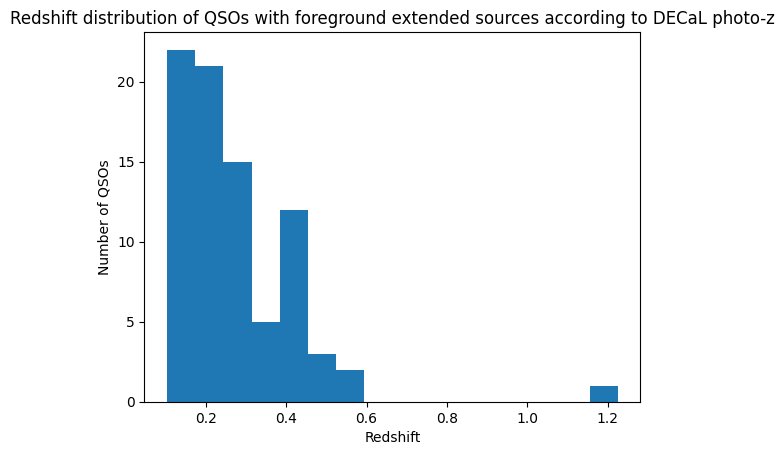

In [129]:
unique_qsos, unique_idx = np.unique(photoz_foreground['DESI_QSO_ID'], return_index=True)
print(f"Number of unique QSOs with foreground according to DECaL photo-z: {len(unique_qsos)}")

plt.hist(photoz_foreground['QSO_z'][unique_idx], bins='auto')
plt.xlabel("Redshift")
plt.ylabel("Number of QSOs")
plt.title("Redshift distribution of QSOs with foreground extended sources according to DECaL photo-z")
plt.show()